# Economics S5040 | Problem Set 4
### Dynamic Programming

**Name:** Friedman

This notebook works through the growth model and two finite-state decision problems. Monetary amounts in Problems 3 and 4 are in millions of dollars. Running the cells in order reproduces the numerical results and figures.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

try:
    import quantecon as qe
except ImportError:
    qe = None

plt.rcParams.update({"figure.figsize": (7.5, 4.2), "axes.spines.top": False,
                     "axes.spines.right": False, "font.size": 10})
pd.options.display.float_format = "{:,.6f}".format

## Problem 1. Bellman and Euler equations

**(a)** The state is capital $k_t>0$ at the start of period $t$. The control is next period's capital $k_{t+1}$, constrained by $0<k_{t+1}<A k_t^\alpha$. Current consumption is the residual $c_t=A k_t^\alpha-k_{t+1}$. The one-period reward is $\log c_t$, the transition rule sets next period's state equal to the chosen $k_{t+1}$, and the discount factor is $\beta$.

**(b)** With $f(k)=Ak^\alpha$, the Bellman equation is

$$V(k)=\max_{0<k'<f(k)}\left\{\log[f(k)-k']+\beta V(k')\right\}.$$

**(c)** At an interior optimum, differentiating with respect to $k'$ gives

$$-\frac{1}{f(k)-k'}+\beta V'(k')=0,
\qquad\text{or}\qquad u'(c_t)=\beta V'(k_{t+1}).$$

**(d)** The envelope condition is $V'(k_t)=u'(c_t)f'(k_t)$. Applying it at $t+1$ to the first-order condition yields

$$u'(c_t)=\beta u'(c_{t+1})f'(k_{t+1})
=\beta\frac{\alpha A k_{t+1}^{\alpha-1}}{c_{t+1}}.$$

Thus $u'(c_t)/[\beta u'(c_{t+1})]$, the intertemporal marginal rate of substitution, equals the gross marginal output from investing one more unit of current goods. Full depreciation is built into the resource constraint, so there is no extra undepreciated-capital term.

**(e)** Guess $V(k)=E+F\log k$. Substituting into the Bellman equation gives

$$\frac{1}{Ak^\alpha-k'}=\frac{\beta F}{k'},
\qquad k'=\frac{\beta F}{1+\beta F}Ak^\alpha.$$

The coefficient on $\log k$ on the right is $\alpha(1+\beta F)$, so $F=\alpha(1+\beta F)=\alpha/(1-\alpha\beta)$. Consequently $\beta F/(1+\beta F)=\alpha\beta$, and

$$\boxed{k_{t+1}=\alpha\beta A k_t^\alpha},\qquad
\boxed{c_t=(1-\alpha\beta)Ak_t^\alpha}.$$

For completeness, $E=[\log((1-\alpha\beta)A)+\beta F\log(\alpha\beta A)]/(1-\beta)$. The implied saving share of output is $\alpha\beta$.

### (f) and (g) Capital paths and patience

,saving share,analytical k*,simulated k_50,absolute error
beta,,,,
0.800000,0.280000,0.409824,0.409824,0.000000
0.950000,0.332500,0.533848,0.533848,0.000000
0.990000,0.346500,0.568819,0.568819,0.000000


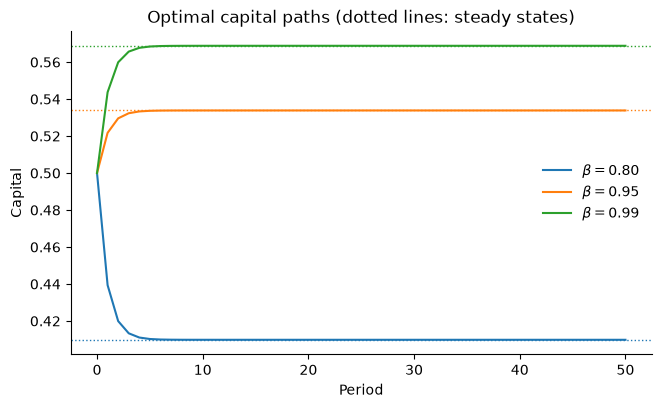

In [2]:
A = 2.0
alpha = 0.35
k0 = 0.5
T = 50

def optimal_capital_path(A, alpha, beta, k0, T):
    path = np.empty(T + 1)
    path[0] = k0
    for t in range(T):
        path[t + 1] = alpha * beta * A * path[t] ** alpha
    return path

betas = [0.80, 0.95, 0.99]
paths = {beta: optimal_capital_path(A, alpha, beta, k0, T) for beta in betas}
steady_capital = {beta: (alpha * beta * A) ** (1 / (1 - alpha)) for beta in betas}

growth_results = pd.DataFrame({
    "beta": betas,
    "saving share": [alpha * beta for beta in betas],
    "analytical k*": [steady_capital[beta] for beta in betas],
    "simulated k_50": [paths[beta][-1] for beta in betas],
    "absolute error": [abs(paths[beta][-1] - steady_capital[beta]) for beta in betas],
}).set_index("beta")
display(growth_results)
assert all(abs(paths[b][-1] - steady_capital[b]) < 1e-10 for b in betas)

fig, ax = plt.subplots()
for beta in betas:
    line, = ax.plot(range(T + 1), paths[beta], label=fr"$\beta={beta:.2f}$")
    ax.axhline(steady_capital[beta], color=line.get_color(), linestyle=":", linewidth=1)
ax.set(title="Optimal capital paths (dotted lines: steady states)",
       xlabel="Period", ylabel="Capital")
ax.legend(frameon=False)
plt.show()

The steady state solves $k^*=\alpha\beta A(k^*)^\alpha$, hence $k^*=(\alpha\beta A)^{1/(1-\alpha)}$. After 50 transitions the simulated values agree with the analytical steady states to numerical precision. A higher $\beta$ raises the payoff from future consumption, so the household saves the larger share $\alpha\beta$ and eventually holds more capital. From $k_0=0.5$, the path falls when $\beta=0.80$ and rises when $\beta=0.95$ or $0.99$ because the initial stock lies on different sides of the corresponding steady states.

## Problem 2. A small controlled Markov problem

**(a)** Write $(V_S,V_O,V_G)$ for the values of Sick, Okay, and Great. The three Bellman equations are

$$\begin{aligned}
V_S&=\max\{1+\beta(0.5V_S+0.5V_O),\;-1+\beta(0.9V_S+0.1V_O)\},\\
V_O&=\max\{2+\beta(0.1V_S+0.4V_O+0.5V_G),\;1+\beta(0.3V_S+0.6V_O+0.1V_G)\},\\
V_G&=\max\{8+\beta(0.4V_O+0.6V_G),\;5+\beta(0.3V_S+0.6V_O+0.1V_G)\}.
\end{aligned}$$

Here $\beta=0.5$ and the first term inside each maximum is TV.

In [3]:
states = ["Sick", "Okay", "Great"]
controls = ["TV", "Study"]
R_student = np.array([[1.0, -1.0], [2.0, 1.0], [8.0, 5.0]])
M_tv = np.array([[0.5, 0.5, 0.0], [0.1, 0.4, 0.5], [0.0, 0.4, 0.6]])
M_study = np.array([[0.9, 0.1, 0.0], [0.3, 0.6, 0.1], [0.3, 0.6, 0.1]])
beta_student = 0.5
transition_student = [M_tv, M_study]

### (b) and (c) Policy evaluation and one Howard improvement

In [4]:
V_tv = np.linalg.solve(np.eye(len(states)) - beta_student * M_tv, R_student[:, 0])
student_choices = np.column_stack([
    R_student[:, action] + beta_student * matrix @ V_tv
    for action, matrix in enumerate(transition_student)
])
howard_policy = [controls[action] for action in student_choices.argmax(axis=1)]
display(pd.DataFrame({
    "V under all-TV": V_tv,
    "TV today": student_choices[:, 0],
    "Study today": student_choices[:, 1],
    "improved policy": howard_policy,
}, index=states))

,V under all-TV,TV today,Study today,improved policy
Sick,3.638796,3.638796,0.983278,TV
Okay,6.916388,6.916388,4.290970,TV
Great,13.404682,13.404682,8.290970,TV


### (d) to (f) Value iteration, comparison, and stationary probabilities

In [5]:
def bellman(V, R, transitions, beta):
    choices = np.column_stack([
        R[:, action] + beta * matrix @ V
        for action, matrix in enumerate(transitions)
    ])
    return choices.max(axis=1), choices.argmax(axis=1)

V_student = np.zeros(len(states))
for student_iterations in range(1, 10001):
    updated, actions = bellman(V_student, R_student, transition_student, beta_student)
    if np.max(np.abs(updated - V_student)) < 1e-10:
        V_student = updated
        break
    V_student = updated
else:
    raise RuntimeError("Student value iteration did not converge")

student_policy = [controls[action] for action in actions]
P_student = np.vstack([transition_student[action][i] for i, action in enumerate(actions)])
system = np.eye(len(states)) - P_student.T
system[-1, :] = 1
rhs = np.array([0.0, 0.0, 1.0])
student_stationary = np.linalg.solve(system, rhs)

display(pd.DataFrame({
    "value iteration": V_student,
    "Howard policy": howard_policy,
    "optimal policy": student_policy,
    "stationary probability": student_stationary,
}, index=states))
print(f"Value iteration converged in {student_iterations} updates")
print("Optimal-policy transition matrix:")
display(pd.DataFrame(P_student, index=states, columns=states))
assert np.allclose(V_student, V_tv, atol=1e-9)
assert student_policy == howard_policy

,value iteration,Howard policy,optimal policy,stationary probability
Sick,3.638796,TV,TV,0.081633
Okay,6.916388,TV,TV,0.408163
Great,13.404682,TV,TV,0.510204


Value iteration converged in 37 updates
Optimal-policy transition matrix:


,Sick,Okay,Great
Sick,0.500000,0.500000,0.000000
Okay,0.100000,0.400000,0.500000
Great,0.000000,0.400000,0.600000


Howard's improvement step leaves the all-TV policy unchanged: in every health state, TV has a higher current reward and a higher one-step value using the evaluated continuation values. Value iteration reaches the same Bellman fixed point by repeatedly updating values from zero; policy improvement instead solves a linear system for a fixed policy before comparing actions. The numerical paths differ even though the optimal policy agrees. Under that policy, the long-run fractions of periods spent Sick, Okay, and Great are about $8.16\%$, $40.82\%$, and $51.02\%$. These describe long-run state frequencies, not a guarantee about any particular student's realized sequence.

## Problem 3. The advertising decision

**(1)** The state is the current sales category (Bad, Normal, or Good). The control is No Buy or Buy. The current reward is sales less the $1 million advertising cost if there is a buy. The chosen action selects the row of its Markov transition matrix, and the discount factor is $\beta=0.9$.

**(2)** In a Normal year, the Bellman equation is

$$V_N=\max\left\{2+\beta(0.2V_B+0.8V_N),\;
1+\beta(0.1V_B+0.6V_N+0.3V_G)\right\}.$$

Current sales are $2 million under either choice; buying an ad changes current net profit and the distribution of future states.

### (3) and (4) Model inputs

In [6]:
States = ["Bad", "Normal", "Good"]
Controls = ["No Buy", "Buy"]
reward = np.array([[1.0, 0.0], [2.0, 1.0], [4.0, 3.0]])
M0 = np.array([[0.8, 0.2, 0.0], [0.2, 0.8, 0.0], [0.1, 0.4, 0.5]])
M1 = np.array([[0.5, 0.5, 0.0], [0.1, 0.6, 0.3], [0.1, 0.3, 0.6]])
beta = 0.9
V0 = np.zeros(len(States))
transition = {"No Buy": M0, "Buy": M1}

### (5) to (9) Validate, update, solve, and recover the policy

In [7]:
def check_dp(V, reward, transition, beta):
    V = np.asarray(V, dtype=float)
    reward = np.asarray(reward, dtype=float)
    if V.ndim != 1 or reward.shape != (len(V), len(transition)):
        raise ValueError("Value and reward dimensions do not match")
    if not np.isfinite(V).all() or not np.isfinite(reward).all():
        raise ValueError("Values and rewards must be finite")
    if not np.isfinite(beta) or not 0 < beta < 1:
        raise ValueError("Discount factor must lie strictly between 0 and 1")
    for matrix in transition.values():
        matrix = np.asarray(matrix, dtype=float)
        if matrix.shape != (len(V), len(V)) or not np.isfinite(matrix).all():
            raise ValueError("Each transition matrix must be finite and square")
        if (matrix < 0).any() or not np.allclose(matrix.sum(axis=1), 1):
            raise ValueError("Transition rows must be nonnegative and sum to one")
    return True

def get_transition(state, control, transition):
    state_index = States.index(state) if isinstance(state, str) else state
    return transition[control][state_index].copy()

def update_value(V, States, Controls, reward, transition, beta):
    choices = np.column_stack([
        reward[:, j] + beta * transition[control] @ V
        for j, control in enumerate(Controls)
    ])
    return choices.max(axis=1)

def solve_value(V0, States, Controls, reward, transition, beta,
                tol=1e-10, max_iter=10000):
    check_dp(V0, reward, transition, beta)
    V = np.asarray(V0, dtype=float).copy()
    for iteration in range(1, max_iter + 1):
        new_V = update_value(V, States, Controls, reward, transition, beta)
        if np.max(np.abs(new_V - V)) < tol:
            return new_V, iteration
        V = new_V
    raise RuntimeError("Value iteration did not converge")

def optimal_policy(V, States, Controls, reward, transition, beta):
    choices = np.column_stack([
        reward[:, j] + beta * transition[control] @ V
        for j, control in enumerate(Controls)
    ])
    return [Controls[j] for j in choices.argmax(axis=1)]

assert check_dp(V0, reward, transition, beta)
print("Normal-year transition probabilities after an ad:",
      get_transition("Normal", "Buy", transition))
print("One Bellman update from zero:", update_value(V0, States, Controls, reward, transition, beta))
V_ad, ad_iterations = solve_value(V0, States, Controls, reward, transition, beta)
ad_policy = optimal_policy(V_ad, States, Controls, reward, transition, beta)
print(f"Converged in {ad_iterations} updates; policy: {dict(zip(States, ad_policy))}")

Normal-year transition probabilities after an ad: [0.1 0.6 0.3]
One Bellman update from zero: [1. 2. 4.]
Converged in 225 updates; policy: {'Bad': 'No Buy', 'Normal': 'Buy', 'Good': 'No Buy'}


### (10) and (11) Policy transition matrix, ergodic distribution, and results

In [8]:
def policy_transition(policy, States, transition):
    if len(policy) != len(States):
        raise ValueError("Policy length must equal the number of states")
    return np.vstack([transition[action][i] for i, action in enumerate(policy)])

def stationary_distribution(P):
    P = np.asarray(P, dtype=float)
    system = np.eye(len(P)) - P.T
    system[-1, :] = 1
    rhs = np.zeros(len(P))
    rhs[-1] = 1
    probabilities = np.linalg.solve(system, rhs)
    if probabilities.min() < -1e-10:
        raise ValueError("Invalid stationary distribution")
    probabilities = np.maximum(probabilities, 0)
    return probabilities / probabilities.sum()

P_ad = policy_transition(ad_policy, States, transition)
pi_ad = stationary_distribution(P_ad)
ad_results = pd.DataFrame({
    "No Buy reward": reward[:, 0],
    "Buy reward": reward[:, 1],
    "Value": V_ad,
    "Optimal policy": ad_policy,
    "Ergodic probability": pi_ad,
}, index=pd.Index(States, name="State"))
display(ad_results)
print("Optimal-policy transition matrix:")
display(pd.DataFrame(P_ad, index=States, columns=States))
assert np.allclose(pi_ad @ P_ad, pi_ad)
assert np.isclose(pi_ad.sum(), 1)
assert np.allclose(V_ad, reward[np.arange(3), [Controls.index(a) for a in ad_policy]] + beta * P_ad @ V_ad, atol=1e-8)

,No Buy reward,Buy reward,Value,Optimal policy,Ergodic probability
State,,,,,
Bad,1.000000,0.000000,14.805537,No Buy,0.333333
Normal,2.000000,1.000000,17.475280,Buy,0.416667
Good,4.000000,3.000000,21.133817,No Buy,0.250000


Optimal-policy transition matrix:


,Bad,Normal,Good
Bad,0.800000,0.200000,0.000000
Normal,0.100000,0.600000,0.300000
Good,0.100000,0.400000,0.500000


### (12) A reusable DP Markov class

In [9]:
class DP_Markov:
    def __init__(self, states, controls, reward, transition, beta):
        self.states = list(states)
        self.controls = list(controls)
        self.reward = np.asarray(reward, dtype=float)
        self.transition = {key: np.asarray(value, dtype=float)
                           for key, value in transition.items()}
        self.beta = beta
        if len(self.states) != self.reward.shape[0] or set(self.controls) != set(self.transition):
            raise ValueError("State or control labels do not match the model")
        check_dp(np.zeros(len(self.states)), self.reward, self.transition, beta)
        self.value = None

    def transition_probs(self, state, control):
        i = self.states.index(state) if isinstance(state, str) else state
        return self.transition[control][i].copy()

    def choices(self, value):
        return np.column_stack([
            self.reward[:, j] + self.beta * self.transition[action] @ value
            for j, action in enumerate(self.controls)
        ])

    def bellman(self, value):
        return self.choices(value).max(axis=1)

    def solve(self, value=None, tol=1e-10, max_iter=10000):
        current = np.zeros(len(self.states)) if value is None else np.asarray(value, dtype=float).copy()
        for iteration in range(1, max_iter + 1):
            updated = self.bellman(current)
            if np.max(np.abs(updated - current)) < tol:
                self.value = updated
                self.iterations = iteration
                return updated
            current = updated
        raise RuntimeError("Value iteration did not converge")

    def policy(self):
        if self.value is None:
            self.solve()
        return [self.controls[j] for j in self.choices(self.value).argmax(axis=1)]

    def policy_matrix(self):
        return np.vstack([self.transition[action][i]
                          for i, action in enumerate(self.policy())])

    def ergodic_distribution(self):
        return stationary_distribution(self.policy_matrix())

    def summary(self):
        if self.value is None:
            self.solve()
        result = {f"{action} reward": self.reward[:, j]
                  for j, action in enumerate(self.controls)}
        result.update({"Value": self.value, "Optimal policy": self.policy(),
                       "Ergodic probability": self.ergodic_distribution()})
        return pd.DataFrame(result, index=pd.Index(self.states, name="State"))

ad_model = DP_Markov(States, Controls, reward, transition, beta)
display(ad_model.summary())
assert np.allclose(ad_model.value, V_ad)
assert ad_model.policy() == ad_policy

,No Buy reward,Buy reward,Value,Optimal policy,Ergodic probability
State,,,,,
Bad,1.000000,0.000000,14.805537,No Buy,0.333333
Normal,2.000000,1.000000,17.475280,Buy,0.416667
Good,4.000000,3.000000,21.133817,No Buy,0.250000


The optimal policy is No Buy in Bad and Good years and Buy in Normal years. The stationary probabilities are $1/3$, $5/12$, and $1/4$ for Bad, Normal, and Good. Notice that buying in a Normal year is worthwhile despite the $1 million immediate cost: it creates a $0.3$ chance of moving directly to Good next year, while not buying gives no such chance.

## Problem 4. Economics of the advertising policy

### (a) and (b) Actions and long-run outcomes

In [10]:
sales = reward[:, 0].copy()
choice_values = np.column_stack([
    reward[:, j] + beta * transition[action] @ V_ad
    for j, action in enumerate(Controls)
])
ad_comparison = pd.DataFrame({
    "No Buy value": choice_values[:, 0],
    "Buy value": choice_values[:, 1],
    "Buy minus No Buy": choice_values[:, 1] - choice_values[:, 0],
    "Best action": ad_policy,
}, index=States)
display(ad_comparison)

ad_indicator = np.array([action == "Buy" for action in ad_policy], dtype=float)
long_run_sales = pi_ad @ sales
ad_frequency = pi_ad @ ad_indicator
long_run_profit = pi_ad @ (sales - ad_indicator)
print(f"Long-run sales: ${long_run_sales:.6f} million per year")
print(f"Advertising frequency: {ad_frequency:.6f} of years")
print(f"Long-run net profit: ${long_run_profit:.6f} million per year")

,No Buy value,Buy value,Buy minus No Buy,Best action
Bad,14.805537,14.526368,-0.279169,No Buy
Normal,17.247198,17.475280,0.228082,Buy
Good,21.133817,20.463085,-0.670732,No Buy


Long-run sales: $2.166667 million per year
Advertising frequency: 0.416667 of years
Long-run net profit: $1.750000 million per year


The cost is the same in every state, but the gain in discounted future value is state dependent. In a Bad year, advertising only improves the chance of reaching Normal. In a Normal year, it opens a route to Good that No Buy lacks, and this benefit exceeds the cost. In a Good year, the improvement in persistence is too small to justify the cost. In the long run the firm spends $1 million in the $5/12$ of years that are Normal, so average net profit is $13/6-5/12=7/4$, or $1.75$ million per year.

### (c) Advertising cost and the optimal action

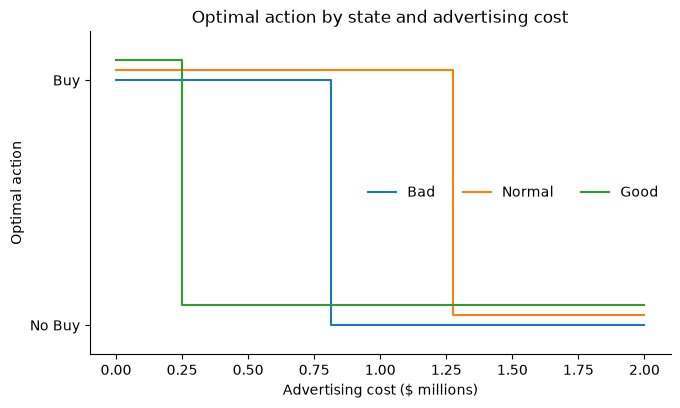

,Cost from,"Policy (Bad, Normal, Good)"
0,0.000000,"(Buy, Buy, Buy)"
1,0.250000,"(Buy, Buy, No Buy)"
2,0.815000,"(No Buy, Buy, No Buy)"
3,1.275000,"(No Buy, No Buy, No Buy)"


In [11]:
def solve_ad_model(cost, discount):
    reward_at_cost = np.column_stack([sales, sales - cost])
    value, _ = solve_value(np.zeros(len(States)), States, Controls,
                           reward_at_cost, transition, discount)
    policy = optimal_policy(value, States, Controls, reward_at_cost,
                            transition, discount)
    return value, policy

cost_grid = np.linspace(0, 2, 401)
policies_by_cost = []
for cost in cost_grid:
    _, policy = solve_ad_model(cost, beta)
    policies_by_cost.append(policy)
cost_actions = np.array([[action == "Buy" for action in policy]
                         for policy in policies_by_cost], dtype=int)

fig, ax = plt.subplots()
for i, state in enumerate(States):
    ax.step(cost_grid, cost_actions[:, i] + 0.04 * i, where="post", label=state)
ax.set(xlabel="Advertising cost ($ millions)", ylabel="Optimal action",
       yticks=[0, 1], yticklabels=["No Buy", "Buy"],
       ylim=(-0.12, 1.20), title="Optimal action by state and advertising cost")
ax.legend(frameon=False, ncol=3, loc="center right")
plt.show()

cost_switches = [(cost_grid[0], tuple(policies_by_cost[0]))]
for i in range(1, len(cost_grid)):
    if policies_by_cost[i] != policies_by_cost[i - 1]:
        cost_switches.append((cost_grid[i], tuple(policies_by_cost[i])))
display(pd.DataFrame(cost_switches, columns=["Cost from", "Policy (Bad, Normal, Good)"]))

As the cost rises, buying first stops in Good, then Bad, and finally Normal. On this $0.005$ grid, the changes appear near $c=0.25$, $0.815$, and $1.275$ million. The exact tie points can fall between grid points; at a tie either action is optimal for that state.

### (d) Cost, the stationary mix, and long-run sales

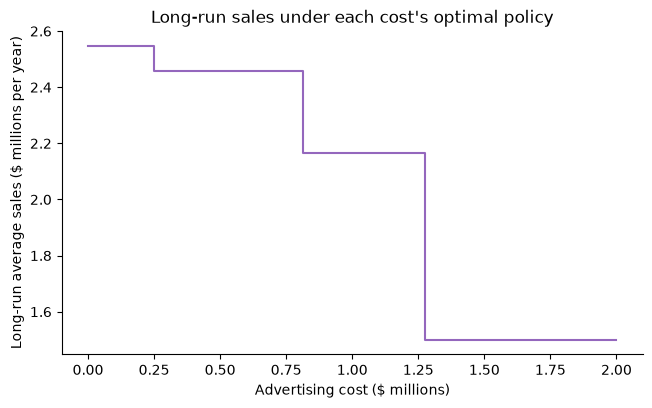

,Cost,Long-run sales,Bad probability,Normal probability,Good probability
0,0.000000,2.547619,0.166667,0.476190,0.357143
1,1.000000,2.166667,0.333333,0.416667,0.250000
2,2.000000,1.500000,0.500000,0.500000,0.000000


In [12]:
stationary_by_cost = np.array([
    stationary_distribution(policy_transition(policy, States, transition))
    for policy in policies_by_cost
])
sales_by_cost = stationary_by_cost @ sales

fig, ax = plt.subplots()
ax.step(cost_grid, sales_by_cost, where="post", color="tab:purple")
ax.set(xlabel="Advertising cost ($ millions)",
       ylabel="Long-run average sales ($ millions per year)",
       title="Long-run sales under each cost's optimal policy")
plt.show()

display(pd.DataFrame({"Cost": [0.0, 1.0, 2.0],
                      "Long-run sales": [sales_by_cost[0], sales_by_cost[200], sales_by_cost[-1]],
                      "Bad probability": [stationary_by_cost[i, 0] for i in [0, 200, 400]],
                      "Normal probability": [stationary_by_cost[i, 1] for i in [0, 200, 400]],
                      "Good probability": [stationary_by_cost[i, 2] for i in [0, 200, 400]]}))

The stationary distribution, and therefore average sales, is constant while a particular policy remains optimal because the transition matrices themselves do not depend on cost. A policy switch changes at least one row of the policy transition matrix. Its stationary distribution can then change abruptly, producing the jumps in sales. This does not imply a jump in the optimized discounted value: near a switching point, two policies can have nearly the same value despite different long-run sales and advertising outlays.

### (e) Patience and the advertising policy

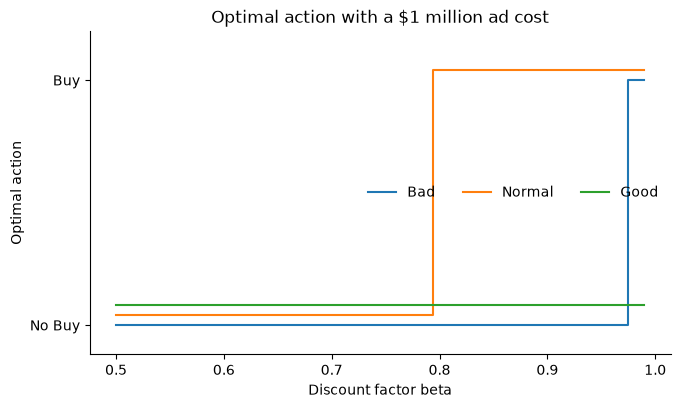

,Beta from,"Policy (Bad, Normal, Good)"
0,0.500000,"(No Buy, No Buy, No Buy)"
1,0.794000,"(No Buy, Buy, No Buy)"
2,0.975000,"(Buy, Buy, No Buy)"


In [13]:
beta_grid = np.linspace(0.50, 0.99, 491)
policies_by_beta = []
for discount in beta_grid:
    _, policy = solve_ad_model(1.0, discount)
    policies_by_beta.append(policy)
beta_actions = np.array([[action == "Buy" for action in policy]
                         for policy in policies_by_beta], dtype=int)

fig, ax = plt.subplots()
for i, state in enumerate(States):
    ax.step(beta_grid, beta_actions[:, i] + 0.04 * i, where="post", label=state)
ax.set(xlabel="Discount factor beta", ylabel="Optimal action",
       yticks=[0, 1], yticklabels=["No Buy", "Buy"],
       ylim=(-0.12, 1.20), title="Optimal action with a $1 million ad cost")
ax.legend(frameon=False, ncol=3, loc="center right")
plt.show()

beta_switches = [(beta_grid[0], tuple(policies_by_beta[0]))]
for i in range(1, len(beta_grid)):
    if policies_by_beta[i] != policies_by_beta[i - 1]:
        beta_switches.append((beta_grid[i], tuple(policies_by_beta[i])))
display(pd.DataFrame(beta_switches, columns=["Beta from", "Policy (Bad, Normal, Good)"]))

At a $1 million cost, no state advertises at low $\beta$. Normal starts buying at about $\beta=0.794$; Bad starts only around $0.975$. Good never buys on this range. More patience raises the weight placed on the improved future-state distribution, so the firm is willing to pay now for benefits that may persist for several years.

### (f) Why a one-year sales rule fails

The correct comparison in state $s$ is

$$Q(s,\mathrm{Buy})-Q(s,\mathrm{No\ Buy})
=-c+\beta\sum_{s'}[P_{\mathrm{Buy}}(s,s')-P_{\mathrm{No\ Buy}}(s,s')]V(s').$$

The manager's rule replaces the continuation value $V(s')$ by next year's sales, ignores later years and the discount factor, and compares a next-year difference with a cost paid now. The expected increases in **next year's** sales are only $0.3$, $0.7$, and $0.2$ million in Bad, Normal, and Good, respectively. The proposed rule would therefore never buy at a $1 million cost. Yet buying in Normal is optimal at $\beta=0.9$ because it improves the entire discounted stream of future profit, not just next year's sales.

## Problem 5. What have we learned?

A dynamic program starts with a **state**, the information needed for today's decision and tomorrow's state. In the growth problem it is current capital. In the advertising problem it is the firm's current sales category. A **control** is the choice made after seeing that state: next period's capital in one model, or whether to buy an ad in the other. The **reward** measures what that choice yields today. For growth it is the utility of consumption left after saving; for advertising it is current sales less the ad cost. The **transition rule** tells us which state can follow the current state and control. Capital evolves deterministically, while the advertising matrices give probabilities for next year's sales category.

The **value function** adds current and expected future rewards, with future rewards discounted. It measures the worth of starting in a state when future choices are optimal. The **policy function** then tells us which control attains that value in each state. A policy can differ across states even when the dollar cost of an action does not. In Problem 4, ads can lead directly from Normal to Good but do not pay off in Good.

The Bellman equation converts an infinite-horizon problem into a one-period choice plus a continuation value. For every available control, I calculate today's reward and the discounted expected value of the state that follows. Maximizing this sum gives the value today. The recursion works because the same decision problem begins again next period, with its new state. It also makes clear why a rule based only on next year's expected sales can miss the best advertising choice: the continuation value includes outcomes farther ahead and the choices the firm will make in those future states.

Value function iteration and Howard policy improvement use the same Bellman equation but organize the computation differently. Value iteration starts with a guess for the values and repeatedly applies the Bellman maximum. Howard's method fixes a policy, solves exactly for the values implied by following it, and then checks whether another action would improve each state. In the student example, the initial all-TV policy already passes that check, while value iteration takes many updates from zero to reach the same answer. Both methods seek the same optimal values and policy; they just take different routes there.

## What surprised me?

I expected the firm to advertise in Good years to preserve its strong sales, but the optimal policy says No Buy there and Buy in Normal years. The Good-year ad raises the probability of remaining Good only from $0.5$ to $0.6$, while a Normal-year ad creates a $0.3$ chance of reaching Good that is otherwise zero. Seeing the continuation values made it clear that the size of the improvement matters relative to the current state and the $1 million cost, not just whether advertising improves the transition probabilities at all.